# Lab 11: Árboles de desición


#Algoritmo CART (classification and regresion tree)

Se busca entrenar un modelo para categorizar la información encontrando la frontera de desición, permite tener una mejor interpretabilidad que las redes neuronales dado que se puede tener una represetancion grafica del proceso de desiscion secuencial.

- ref https://www.youtube.com/watch?v=kqaLlte6P6o&ab_channel=CodificandoBits
- Hand on Machine leargning




In [19]:
from sklearn.datasets import make_classification
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
import graphviz
#from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree
from matplotlib.colors import ListedColormap


Dado un conjunto de caracteristicas se establece una condición que realiza
una particion binaria de los datos a clasificar repitiendo hasta encontrar
particiones lo más homogenea posible.




Text(0, 0.5, '$X_2$')

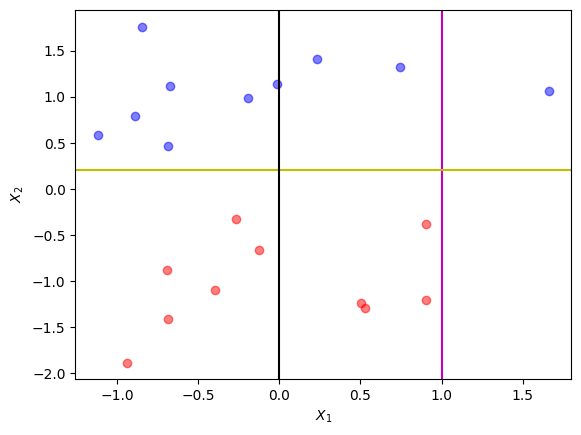

In [6]:
X0, y0 = make_classification(n_samples=20,
    n_features=2, n_redundant=0, n_informative=1, random_state=1,
    n_clusters_per_class=1)

x=np.arange(-2, 3,1)
x_,y_ = np.meshgrid(x,x)

fig, ax = plt.subplots()
ax.plot(X0[:,0][y0==0],X0[:,1][y0==0],"ro", alpha=0.5)
ax.plot(X0[:,0][y0==1],X0[:,1][y0==1],"bo", alpha=0.5)
#ax.plot(x_,y_,"k.")

ax.axvline(x = 1, color = 'm', label="x1<=1")
ax.axhline(y = 0.2, color = 'y', label="x2<0.2")
ax.axvline(x = 0.0, color = 'k', label="x2<0.2")
#plt.legend(loc=3)
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")


- Gini index


$G = 1 - (PC_1)^2 - (PC_2)^2$

$PC_1$: Probablidad categoria 1

$PC_2$: Probablidad categoria 2

Si :

- $G=0$ nodos puros, datos que pertenecen a una sola categoría

- Gini > 0 son nodos con impurezas, con mas de una categoría


La partición purpura  y amarilla del gráfico anterior representan nodos puros.

Mientras que la linea negra define:

- 7 puntos son de color azul.

- 6 puntos de color rojo.

$G = 1 - (7/13)^{2} - (6/13)^{2}$

mientrás que la ponderacion viene dada por:

$m = (7/20+7/20)=7/10$



No:

$G=1-(3/7)^{2}-(4/7)^{2}$
m = (3/20+4/20)


La funcion de coste, asocida al nodo padre:

$J(k, t_k) = \frac{m_{left}}{m} G_{left} + \frac{m_{right}}{m} G_{right} $



# Algoritmo
1. Calcular todos los posibles condiciones.
2. Calcular los indices de Gini.
3. Encontrar la funcion de coste
4. Escoger la menor funcion de coste
5. Repetir.


In [7]:
#IMPLEMENTACION DEL ALGORITMO
X1=1
cond = X0[:, 0] <= X1
grupo_izq = y0[cond]
grupo_der = y0[~cond]

def gini(y):
    clases, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)

gini_izq = gini(grupo_izq)
gini_der = gini(grupo_der)
print("Gini izquierda:", gini_izq)
print("Gini derecha:", gini_der)

m = len(y0)
m_izq = len(grupo_izq)
m_der = len(grupo_der)
J = (m_izq / m) * gini_izq + (m_der / m) * gini_der
print("Función de coste J:", J)

Gini izquierda: 0.4986149584487536
Gini derecha: 0.0
Función de coste J: 0.4736842105263159


In [8]:
#Intento por optimizar el calculo de la funcion de costo por medio de un barrido en las fronteras de decision.
def gini(y):
    clases, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)

mejor_J = 1  # Valor inicial alto
mejor_umbral = None

# Probar todos los valores únicos de X0[:,0] como posibles umbrales
for umbral in np.unique(X0[:, 0]):
    izq = y0[X0[:, 0] <= umbral]
    der = y0[X0[:, 0] > umbral]
    if len(izq) == 0 or len(der) == 0:
        continue
    gini_izq = gini(izq)
    gini_der = gini(der)
    m = len(y0)
    J = (len(izq) / m) * gini_izq + (len(der) / m) * gini_der
    if J < mejor_J:
        mejor_J = J
        mejor_umbral = umbral

print(f"Mejor umbral en X1: {mejor_umbral:.3f}, con función de coste mínima: {mejor_J:.3f}")

Mejor umbral en X1: -0.845, con función de coste mínima: 0.469


### SOLUCION CON LAS FUNCIONES QUE TIENE IMPLEMENTADAS LA LIBRERIA SKLEARN


1. Importar iris dataset


In [9]:
# Cargar el dataset

iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

---
2. Dividir el *dataset* empleanto el metodo train_test_split de sklearn


In [10]:

X = iris.data
y = iris.target

# Dividir en entrenamiento y prueba; para este caso se tuvo en cuenta 70% entrenamiento y 30% prueba

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42, stratify=y )

print("Tamaño Total:", X.shape)
print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño Total: (150, 4)
Tamaño de entrenamiento: (105, 4)
Tamaño de prueba: (45, 4)


---
3. Dentro de sklearn, aplicar el algoritmo DecisionTreeClassifier.


In [11]:

# Crear el clasificador con base en la libreria Sklearn
clf = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo con los datos de entrenamiento
clf.fit(X_train, y_train)

# Evaluacion del desempeño con base en el conjunto de datos sinteticos
score = clf.score(X_test, y_test)
print(f"Precisión en el conjunto de prueba: {score:.2f}")

Precisión en el conjunto de prueba: 0.93


---
4. Para el clasificador analice el gráfico de desición:

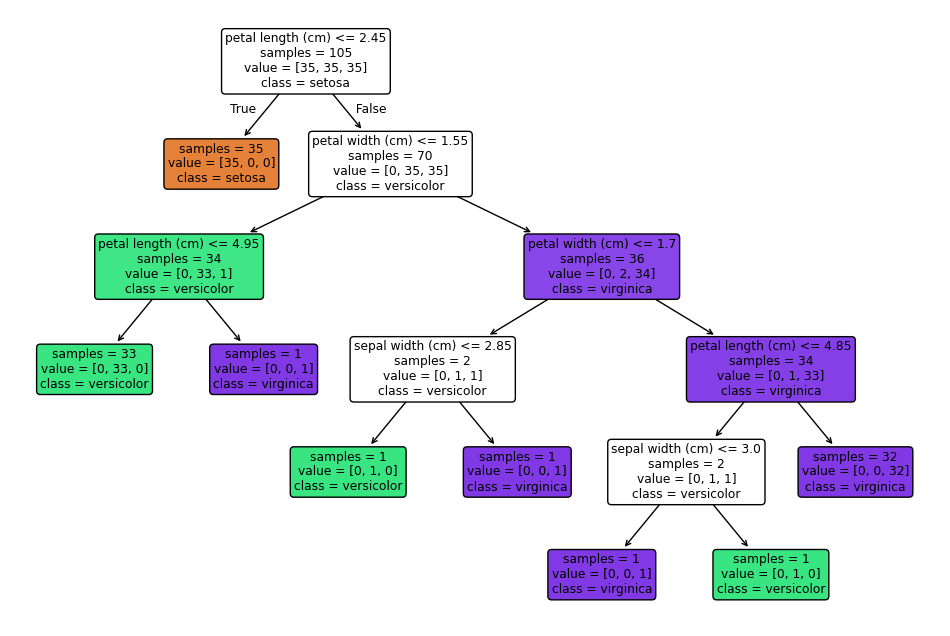

In [12]:
#Grafico de decision

plt.figure(figsize=(12, 8))
tree.plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    impurity=False
)
plt.show()

---
5. Características importantes.

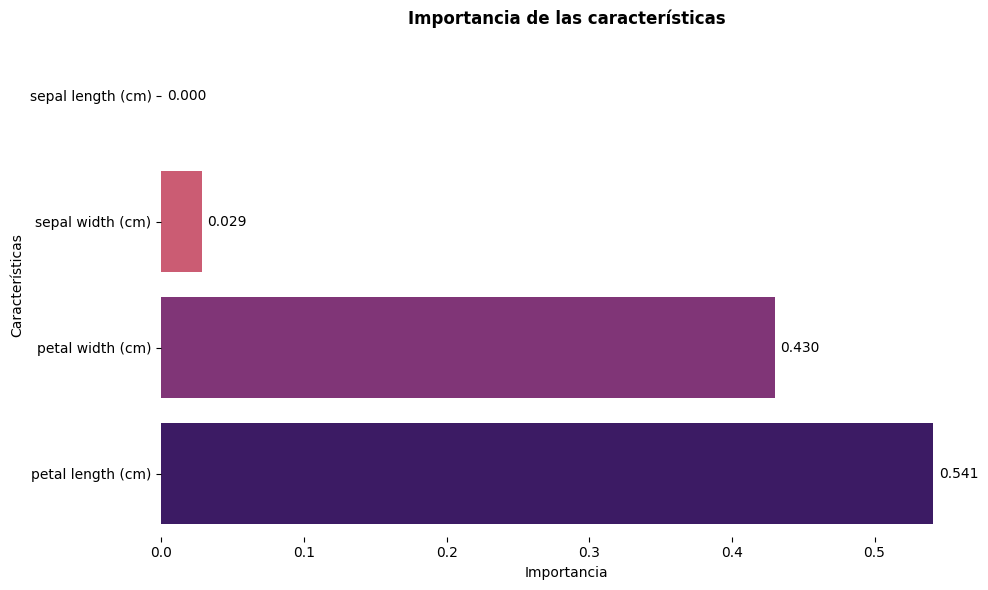

In [33]:
#Grafico de las caracteristicas mas importantes para llevar a acabo la clasificacion.
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_imp = pd.DataFrame({
    "Característica": iris.feature_names,
    "Importancia": importancias
}).sort_values("Importancia", ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_imp,
    x="Importancia",
    y="Característica",
    hue="Característica",
    palette="magma_r",
    legend=False
)

ax.set_title("Importancia de las características", fontsize=12, fontweight="bold")
ax.set_xlabel("Importancia")
ax.set_ylabel("Características")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

---
6. Fronteras de desición.

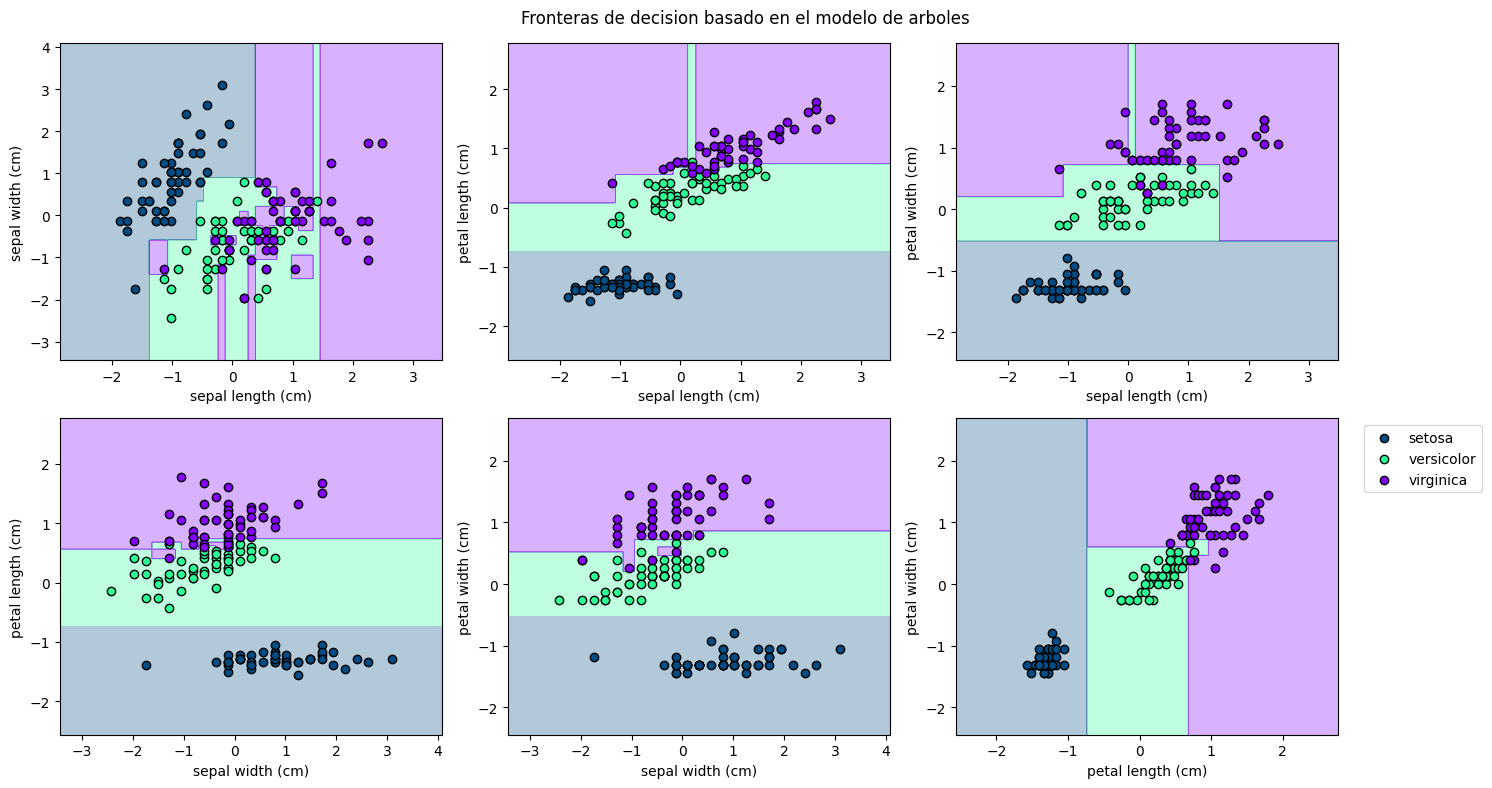

In [ ]:


# Define colores hexadecimales para cada clase
color_1 = "#004d85"
color_2 = "#2cff95"
color_3 = "#8400ff"
custom_colors = [color_1, color_2, color_3]  # azul, verde, violeta
color_dict = {i: custom_colors[i] for i in range(3)}

# Colormap personalizado para las regiones
cmap_custom = ListedColormap(custom_colors)

n_classes = 3
plot_colors = custom_colors
plot_step = 0.02

iris = load_iris()

plt.figure(figsize=(15, 8))
for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                               [1, 2], [1, 3], [2, 3]]):
    # Selecciona dos características
    X = iris.data[:, pair]
    y = iris.target

    # Mezcla aleatoriamente
    idx = np.arange(X.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]

    # Estandariza
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X = (X - mean) / std

    # Entrena el árbol
    clf = DecisionTreeClassifier().fit(X, y)

    # Frontera de decisión
    plt.subplot(2, 3, pairidx + 1)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=cmap_custom, alpha=0.3)

    # Puntos de entrenamiento
    for i, color in color_dict.items():
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], color=color, label=iris.target_names[i], edgecolor='k')

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")

plt.suptitle("Fronteras de decision basado en el modelo de arboles")
plt.legend(loc='best', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()